In [105]:
import cv2                                     # continue 106 th class
import numpy as np
import matplotlib.pyplot as plt
import os

In [98]:
modelConf = "C:\\DS_Py\\04_Deep Learning\\yolov3-tiny.cfg"
modelWeights = "C:\\DS_Py\\04_Deep Learning\\yolov3-tiny.weights"
net = cv2.dnn.readNetFromDarknet(modelConf,modelWeights)
net

< cv2.dnn.Net 00000264581904D0>

In [99]:
classesFile ="coco.names"
with open(classesFile,'rt') as f:
    classes = f.read().rstrip('\n').split('\n')

classes

['person',
 'bicycle',
 'car',
 'motorbike',
 'aeroplane',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic light',
 'fire hydrant',
 'stop sign',
 'parking meter',
 'bench',
 'bird',
 'cat',
 'dog',
 'horse',
 'sheep',
 'cow',
 'elephant',
 'bear',
 'zebra',
 'giraffe',
 'backpack',
 'umbrella',
 'handbag',
 'tie',
 'suitcase',
 'frisbee',
 'skis',
 'snowboard',
 'sports ball',
 'kite',
 'baseball bat',
 'baseball glove',
 'skateboard',
 'surfboard',
 'tennis racket',
 'bottle',
 'wine glass',
 'cup',
 'fork',
 'knife',
 'spoon',
 'bowl',
 'banana',
 'apple',
 'sandwich',
 'orange',
 'broccoli',
 'carrot',
 'hot dog',
 'pizza',
 'donut',
 'cake',
 'chair',
 'sofa',
 'pottedplant',
 'bed',
 'diningtable',
 'toilet',
 'tvmonitor',
 'laptop',
 'mouse',
 'remote',
 'keyboard',
 'cell phone',
 'microwave',
 'oven',
 'toaster',
 'sink',
 'refrigerator',
 'book',
 'clock',
 'vase',
 'scissors',
 'teddy bear',
 'hair drier',
 'toothbrush']

In [100]:
len(classes)      # number of classes

80

In [101]:
dir(net)

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'connect',
 'dump',
 'dumpToFile',
 'dumpToPbtxt',
 'empty',
 'enableFusion',
 'enableWinograd',
 'forward',
 'forwardAndRetrieve',
 'forwardAsync',
 'getFLOPS',
 'getInputDetails',
 'getLayer',
 'getLayerId',
 'getLayerNames',
 'getLayerTypes',
 'getLayersCount',
 'getLayersShapes',
 'getMemoryConsumption',
 'getOutputDetails',
 'getParam',
 'getPerfProfile',
 'getUnconnectedOutLayers',
 'getUnconnectedOutLayersNames',
 'quantize',
 'readFromModelOptimizer',
 'setHalideScheduler',
 'setInput',
 'setInputShape',
 'setInputsNames',
 'setParam',
 'setPreferableBackend',
 'setPreferableTarget']

In [102]:
l=net.getLayerNames()    # number of layers
print(l)
len(l)

('conv_0', 'bn_0', 'leaky_1', 'pool_1', 'conv_2', 'bn_2', 'leaky_3', 'pool_3', 'conv_4', 'bn_4', 'leaky_5', 'pool_5', 'conv_6', 'bn_6', 'leaky_7', 'pool_7', 'conv_8', 'bn_8', 'leaky_9', 'pool_9', 'conv_10', 'bn_10', 'leaky_11', 'pool_11', 'conv_12', 'bn_12', 'leaky_13', 'conv_13', 'bn_13', 'leaky_14', 'conv_14', 'bn_14', 'leaky_15', 'conv_15', 'permute_16', 'yolo_16', 'identity_17', 'conv_18', 'bn_18', 'leaky_19', 'upsample_19', 'concat_20', 'conv_21', 'bn_21', 'leaky_22', 'conv_22', 'permute_23', 'yolo_23')


48

In [103]:
l1=net.getUnconnectedOutLayers()         # yolo layers indexes
l1

array([36, 48], dtype=int32)

In [104]:
l2=net.getUnconnectedOutLayersNames()                # yolo layers names
l2

('yolo_16', 'yolo_23')

# blobfromImage() function #

it returns a 4-dimensional array/blob for the input image. You can additionally use it to preprocess your images.

its different parameters to transform your image.

so let's discuss all its parameters:

**image**

- This is the image that we want to preprocess (for our model)

**scalefactor**

- scale factor basically multiplies (scales) our image channels. And remember that it scales ot down by a factor provide.

**Size**

- This is the target size that we want our image to become. Most common CNNs use 224x224 or 229x229
  it to meet your model requirements.

**mean**

- this is the mean subtracting values. you can input a single value or a 3- item tuple for each channels RGB,
  the channels accordingly.this is done to normalize our pixel values. Note: mean argument utilizes the RGB

**swapRB**

- OpenCV by default reads an image in RGB formate, but as i mentioned above that the mean argument take any disruption this function, as the namme implies swaps the red and blue channels.

In [42]:
frame = cv2.imread("C:\\DS_Py\\03_ML Python\\Benjamin-Franklin.jpg")
frame.shape

(180, 147, 3)

In [43]:
# reshape the image
inpWidth = 116
inpHeight = 116
frame = cv2.imread("C:\\DS_Py\\03_ML Python\\Benjamin-Franklin.jpg")
# generally image will take as BGR , we need to change RGB
blob = cv2.dnn.blobFromImage(frame,1/255 , (inpWidth, inpHeight), [0,0,0],1,crop = False)

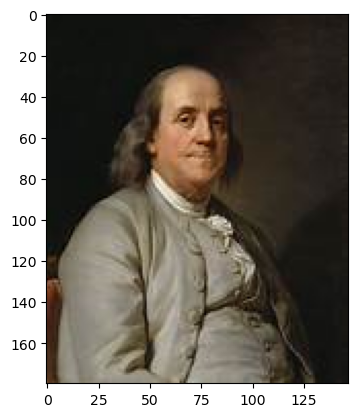

In [44]:
# change BGR to RGB
img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [45]:
frame.shape

(180, 147, 3)

In [46]:
blob.shape       # blob will take in reverse

(1, 3, 116, 116)

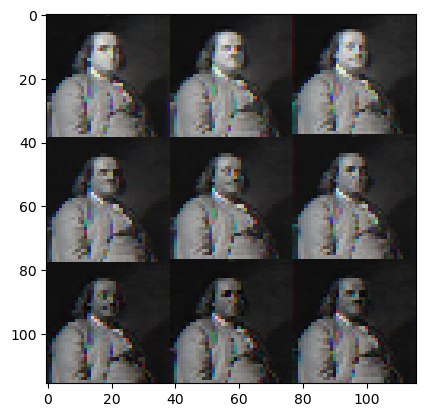

In [47]:
im=blob[0].reshape(116,116,3)
plt.imshow(im)

In [48]:
net.setInput(blob)

# for the yolo arch, we can't pass direct image
# we are converting image into blob

In [53]:
yolo_layers=net.getUnconnectedOutLayersNames()
outs = net.forward(yolo_layers)
outs

# there two yolo layers are there
# in image two objects are there
# we have total 80 classes are there
# we got 85 values 5+80     = 4 bounding box values. 1 confidence value  and 80 classes ==4+1+80=85
# 5 means x,y,w,h. confidence
# 80 means probability of eacch class

(array([[0.19169906, 0.18739326, 0.63777876, ..., 0.        , 0.        ,
         0.        ],
        [0.13624164, 0.12183911, 0.7286731 , ..., 0.        , 0.        ,
         0.        ],
        [0.11954224, 0.16010985, 3.132697  , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.8352199 , 0.82757485, 0.6393832 , ..., 0.        , 0.        ,
         0.        ],
        [0.86385334, 0.8455988 , 0.9401906 , ..., 0.        , 0.        ,
         0.        ],
        [0.8830934 , 0.85578465, 2.952472  , ..., 0.        , 0.        ,
         0.        ]], shape=(48, 85), dtype=float32),
 array([[0.07802497, 0.051394  , 0.08450773, ..., 0.        , 0.        ,
         0.        ],
        [0.07886733, 0.07926522, 0.12650421, ..., 0.        , 0.        ,
         0.        ],
        [0.0487665 , 0.07074565, 0.38871834, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.9263952 , 0.9219142 , 0.07661892, ..., 0.        , 0.        ,
   

In [54]:
len(outs)

2

In [58]:
# in every bounding box 1 confidence will be available and 1 out will be available
len(outs[0])    # 48 bounding boxes are there

48

In [57]:
len(outs[1])     # 192 bounding boxes are there

192

In [61]:
list(outs[0][0])[:5]          # x,y,w,h

[np.float32(0.19169906),
 np.float32(0.18739326),
 np.float32(0.63777876),
 np.float32(0.5982712),
 np.float32(2.5087234e-05)]

**Detect the bounding boxes**

- Those are what are called normalized coordinates.

- To get the width in pixels you would need to multiplay by the width of the image

In [95]:
frameHeight = frame.shape[0]
frameWidth = frame.shape[1]
boxes = []
confidences = []
classIDs=[]
for out in outs: # calling each object boxes
    for detection in out:         # calling each box
        score=detection[5:]            # probability of 80 classes
        class_id=np.argmax(score)      # max probability id
        confidence=score[class_id]     # getting the confidence
        if confidence>0.7:             # if confidence > 70% consider as that is valid bounding box
            # print(detection)
            centerX = int(detection[0] * frameWidth)   # before we pass the object we divided with frame width
            # these are the normalized values so multiplay again
            centerY = int(detection[1] * frameHeight)
            width = int(detection[2] * frameWidth)
            height = int(detection[3] * frameHeight)
            left = int(centerX - width/2)
            top = int(centerY - height/2)

            classIDs.append(class_id)
            confidences.append(float(confidence))
            boxes.append([left, top, width, height])

boxes

[[2, 18, 119, 165], [35, 38, 52, 122]]

In [96]:
confidences

[0.8617337346076965, 0.7508977055549622]

**NMS**: Non Max suppression

**IOU**: intersection of union

**jaccard distance**